# Binomial, Poisson, and Gaussian Probability Distributions



**Goals**  for Kindred Spirits & Lost Souls

- Understand three fundamental discrete/continuous probability distributions:
  - Binomial
  - Poisson
  - Gaussian (Normal)
- See how they arise in simple physics-flavored examples.
- Use Python to:
  - Evaluate the probability mass/density functions
  - Draw random samples
  - Compare histograms of simulated data with theoretical curves

## 0. Imports and basic setup

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from scipy.stats import binom, poisson, norm

np.random.seed(42)  # for reproducible "random" results


# Set parameters fro plots m,ade by matplotlib. rs = "runtime confiuration.
# All subsequent matplotlib plots willl have these features. This is a typing saver.
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["font.size"] = 12

# Other useful examples:
# plt.rcParams["axes.titlesize"] = 14
# plt.rcParams["axes.grid"] = True  


# Reset rcParams to default values.
# All of them at once:
# plt.rcdefaults()

# Individual settings:
# plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]

## 1. Binomial distribution

The **binomial distribution** describes the number of "successes"
in **n independent trials**, each with the same success probability $p$,   
and where there are **only 2 possible outcomes in a trial**. That is where the "bi" in binomail comes from.

Example picture to keep in mind:

- Toss a biased coin $n$ times.
- Success = "heads".
- Random variable $X$ (number of heads).
- $P(X = k)$ means the probability of observing $k$ successes ("heads" in our case)

The explicit expression for the binomial "probability mass function" (PMF) is

\begin{align}
P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k=0,1,\dots,n.
\end{align}

where

\begin{align}
\binom{n}{k} = \frac{n!}{k!(n-k)!}.
\end{align}

Mean and variance:

\begin{align}
\mathbb{E}[X] = np,\qquad \mathrm{Var}(X) = np(1-p).
\end{align}

### 1.1 Example: Photon detection in a counting experiment

Suppose we have a very simple photon detector:

- We send **n = 20** photons at it.
- The detector has a **detection efficiency p = 0.3** (each photon is detected with probability 0.3).
- We assume independence between photons.

Question: What is the probability of detecting exactly \(k\) photons?

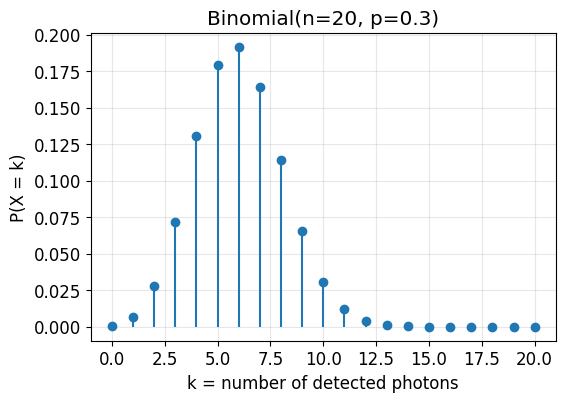

In [5]:
n = 20
p = 0.3

k_vals = np.arange(0, n + 1)
pmf_binomial = binom.pmf(k_vals, n, p)

plt.stem(k_vals, pmf_binomial, basefmt=" ")
plt.xlabel("k = number of detected photons")
plt.ylabel("P(X = k)")
plt.title(f"Binomial(n={n}, p={p})")
plt.grid(alpha=0.3)
plt.show()

### 1.2 Monte Carlo check

Let's simulate many such experiments:

- Each "experiment" = 20 photons sent to the detector.
- Count how many are detected.
- Compare a histogram of simulated counts with the binomial PMF.

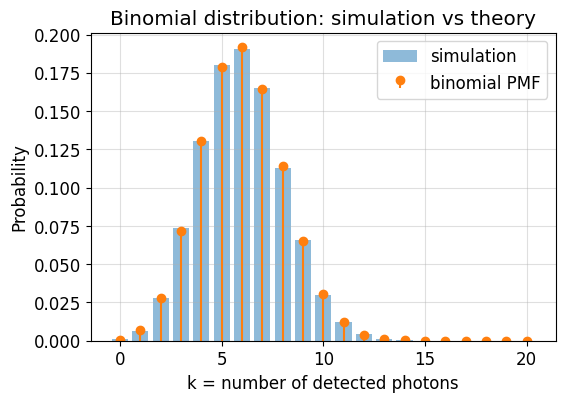

In [6]:
N_experiments = 50_000     # Results are more reliable if you use many experiments.

# Using numpy's binomial sampler
samples_binomial = np.random.binomial(n=n, p=p, size=N_experiments)

# Histogram (normalized)  This means the sum of all the probabilities equals 1.
# Next 2 lines finds centers of histogram bins for better plotting. Each bin has width 1.
# The density=True switch makes the plot "normalized," rather than plotting raw counts
counts, edges = np.histogram(samples_binomial, bins=np.arange(-0.5, n + 1.5, 1), density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

plt.bar(centers, counts, width=0.8, alpha=0.5, label="simulation")
plt.stem(k_vals, pmf_binomial, basefmt=" ", linefmt="C1-", markerfmt="C1o", label="binomial PMF")
plt.xlabel("k = number of detected photons")
plt.ylabel("Probability")
plt.legend()
plt.title("Binomial distribution: simulation vs theory")
plt.grid(alpha=0.4)
plt.show()

## 2. Poisson distribution

The **Poisson distribution** describes the number of events in a fixed interval when:

- Events occur independently and are **discrete**,
- With a constant average rate.

Typical physics examples:

- Number of decays from a radioactive sample in 1 second.
- Number of cosmic-ray hits in a detector during a fixed time interval. The interval time is of your choosing, not something universal.

If the average number of events in the interval is $\lambda$, then

\begin{align}
P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0,1,2,\dots
\end{align}

Mean and variance:

\begin{align}
\mathbb{E}[X] = \lambda,\qquad \mathrm{Var}(X) = \lambda.
\end{align}

### 2.1 Example: Muon counts in a scintillator

Suppose our detector is hit on average by $\bf\lambda = 4$ muons per minute.
What is the probability that in a given minute we see \(k\) hits?

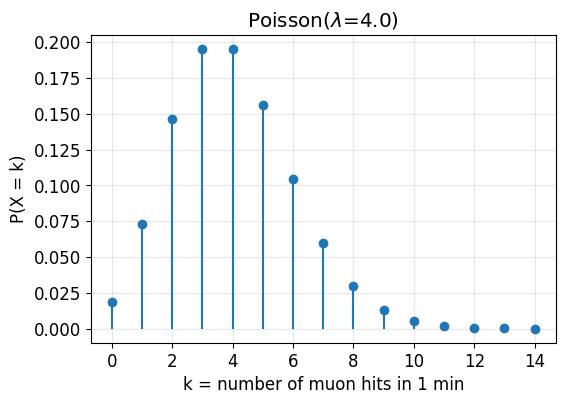

In [7]:
lam = 4.0
k_vals = np.arange(0, 15)
pmf_poisson = poisson.pmf(k_vals, lam)

plt.stem(k_vals, pmf_poisson, basefmt=" ")
plt.xlabel("k = number of muon hits in 1 min")
plt.ylabel("P(X = k)")
plt.title(f"Poisson($\lambda$={lam})")
plt.grid(alpha=0.3)
plt.show()

### 2.2 Monte Carlo: Poisson counts

Let's simulate many minutes of running time and compare with the Poisson PMF.

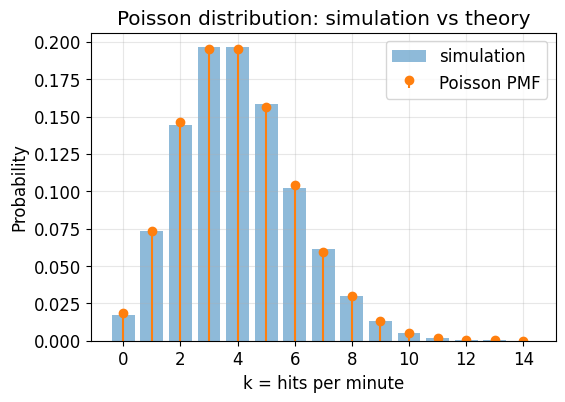

In [8]:
N_minutes = 50_000
samples_poisson = np.random.poisson(lam=lam, size=N_minutes)

counts, edges = np.histogram(samples_poisson, bins=np.arange(-0.5, 15.5, 1), density=True)
centers = 0.5 * (edges[:-1] + edges[1:])

plt.bar(centers, counts, width=0.8, alpha=0.5, label="simulation")
plt.stem(k_vals, pmf_poisson, basefmt=" ", linefmt="C1-", markerfmt="C1o", label="Poisson PMF")
plt.xlabel("k = hits per minute")
plt.ylabel("Probability")
plt.legend()
plt.title("Poisson distribution: simulation vs theory")
plt.grid(alpha=0.3)
plt.show()

### 2.3 Connection to the binomial distribution

A poisson distribution can be obtained as a **limit of the binomial**:

- Consider \(n\) very small time bins in 1 minute.
- In each bin, probability of a hit is \(p\).
- Total mean number of hits is $\lambda = n p$.
- Take $n \to \infty$, $p \to 0$ while keeping $\lambda = n p$ fixed.

Then the binomial distribution for the total events approaches a Poisson distribution:

\begin{align}
\text{Binomial}(n, p = \lambda/n) \;\to\; \text{Poisson}(\lambda).
\end{align}

Let's visualize this for $\lambda = 4$.

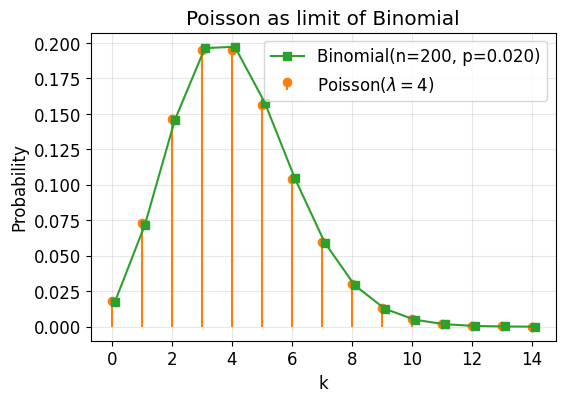

In [10]:
lam = 4.0
n_large = 200  # large n
p_small = lam / n_large

k_vals = np.arange(0, 15)

pmf_bin_approx = binom.pmf(k_vals, n_large, p_small)
pmf_pois = poisson.pmf(k_vals, lam)

plt.stem(k_vals, pmf_pois, basefmt=" ", linefmt="C1-", markerfmt="C1o", label="Poisson($\lambda=4$)")
plt.plot(k_vals + 0.1, pmf_bin_approx, "C2s-", label=f"Binomial(n={n_large}, p={p_small:.3f})")

plt.xlabel("k")
plt.ylabel("Probability")
plt.legend()
plt.title("Poisson as limit of Binomial")
plt.grid(alpha=0.3)
plt.show()

## 3. Gaussian (Normal) distribution

The **Gaussian distribution** is central in physics because of:

- **Central Limit Theorem (CLT)**: sums / averages of many independent
  random contributions tend to be Gaussian.
- Many measurement errors are approximately Gaussian.

The Gaussian probability density function (PDF) with mean \(\mu\) and standard deviation \(\sigma\) is

\begin{align}
f(x) = \frac{1}{\sqrt{2\pi}\,\sigma} \exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right].
\end{align}

Mean and variance:

\begin{align}
\mathbb{E}[X] = \mu,\qquad \mathrm{Var}(X) = \sigma^2.
\end{align}

### 3.1 Example: Measurement errors on a length

Suppose we measure the length of a metal rod.

- True length: $L_\text{true} = 10.0$ cm.
- Instrument has random errors with $\sigma = 0.2$ cm.
- Model: measured values $= L_\text{true} +$ Gaussian "noise" with mean 0 and width $\sigma$.

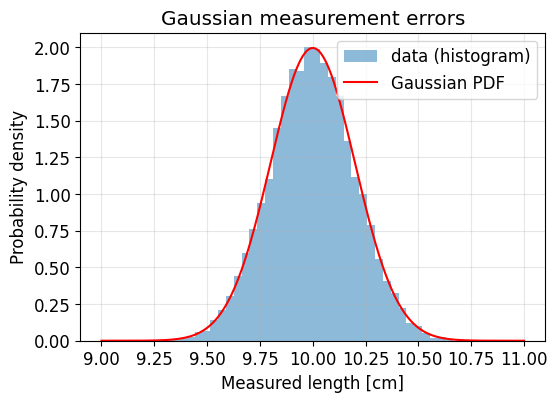

In [11]:
L_true = 10.0      # cm
sigma = 0.2        # cm
N_measurements = 10_000

measurements = L_true + np.random.normal(loc=0.0, scale=sigma, size=N_measurements)

x_min, x_max = 9.0, 11.0
x_vals = np.linspace(x_min, x_max, 400)
pdf_vals = norm.pdf(x_vals, loc=L_true, scale=sigma)

plt.hist(measurements, bins=40, density=True, alpha=0.5, label="data (histogram)")
plt.plot(x_vals, pdf_vals, "r-", label="Gaussian PDF")
plt.xlabel("Measured length [cm]")
plt.ylabel("Probability density")
plt.legend()
plt.title("Gaussian measurement errors")
plt.grid(alpha=0.3)
plt.show()

### 3.2 Central Limit Theorem with Poisson counts

Consider the **muon counts per minute** example:

- In each minute, the count is \(X_i \sim \text{Poisson}(\lambda)\), with \(\lambda = 4\).
- Now average over \(N_\text{avg}\) successive minutes:

\begin{align}
\bar{X} = \frac{1}{N_\text{avg}} \sum_{i=1}^{N_\text{avg}} X_i.
\end{align}

For large \(N_\text{avg}\), the distribution of \(\bar{X}\) becomes approximately *Gaussian*,
even though the \(X_i\) themselves are Poisson.

lam = 4.0
N_avg = 50   # number of minutes in one "block"
N_blocks = 10_000

# Generate N_blocks * N_avg Poisson counts and reshape
all_counts = np.random.poisson(lam=lam, size=N_blocks * N_avg)
block_counts = all_counts.reshape(N_blocks, N_avg)
block_means = block_counts.mean(axis=1)

# According to CLT, mean ≈ λ, variance ≈ λ / N_avg
mu_theory = lam
sigma_theory = np.sqrt(lam / N_avg)

x_vals = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 400)
pdf_gauss = norm.pdf(x_vals, loc=mu_theory, scale=sigma_theory)

plt.hist(block_means, bins=40, density=True, alpha=0.5, label="block means (simulation)")
plt.plot(x_vals, pdf_gauss, "r-", label="Gaussian CLT prediction")
plt.xlabel("Average counts per minute over block")
plt.ylabel("Probability density")
plt.legend()
plt.title(f"CLT: mean of Poisson(λ={lam}) over N_avg={N_avg}")
plt.grid(alpha=0.3)
plt.show()

## 4. Connections between the three distributions

- **Binomial**: number of successes in \(n\) independent trials (fixed \(n\)).  
  Good for repeated yes/no experiments with known probability per trial.

- **Poisson**: number of events in a fixed interval, with rate \(\lambda\).  
  Can be viewed as limit of Binomial with \(n \to \infty\), \(p \to 0\), \(np = \lambda\).  
  Good for radioactive decays, cosmic-ray hits, phone calls per minute, etc.

- **Gaussian** (Normal):
  - Continuous distribution.
  - Emerges as the distribution of the sum/average of many independent contributions
    (by the Central Limit Theorem).
  - For large mean \(\lambda\), a Poisson distribution is well approximated by a Gaussian:

\begin{align}
X \sim \text{Poisson}(\lambda) \approx \mathcal{N}(\mu=\lambda,\ \sigma^2=\lambda).
\end{align}

In experimental physics:

- Count data at low rates → Poisson is more accurate.
- Many counts / averages → Gaussian is usually a good approximation.

### 5. Exercises

1. **Binomial $\to$ Poisson limit**  
   Vary $n$ and $p$ while keeping $np = \lambda$ fixed.  
   Make a **plot** of the maximum absolute difference between the Binomial PMF
   and the Poisson PMF as a function of $n$.

   Guidance:

   Useful functions are `np.abs()` and `np.max()`. For two arrays of same size, `arr1` and `arr2`,

   `max_diff = np.max(np.abs(arr1 - arr2))` tells you the maximum difference between the array entries.

3. **Poisson → Gaussian approximation**  
   For Poisson with \(\lambda = 20\) or \(\lambda = 50\), overlay the Gaussian approximation
   with mean \(\lambda\) and variance \(\lambda\). Quantify how good the approximation is.

4. **Measurement errors**  
   Simulate repeated measurements with different \(\sigma\) values and see how the width
   of the histogram scales with \(\sigma\).

5. **CLT with other distributions**  
   Replace Poisson counts by, say, uniform random numbers in \([0, 1]\).  
   Show that the average of many uniforms tends to a Gaussian as well.